In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

In [29]:
df = pd.read_csv("../data/processed/cleaned_encoded_job_change_data.csv")
df.head()

,city_development_index,experience,last_new_job,training_hours,target,city_city_10,city_city_100,city_city_101,city_city_102,city_city_103,...,company_size_500-999,company_size_5000-9999,company_size_<10,company_size_nan,company_type_Funded Startup,company_type_NGO,company_type_Other,company_type_Public Sector,company_type_Pvt Ltd,company_type_nan
0,0.920,21.0,1.0,36,1.0,False,False,False,False,True,...,False,False,False,True,False,False,False,False,False,True
1,0.776,15.0,5.0,47,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0.624,5.0,0.0,83,0.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
3,0.789,0.0,0.0,52,1.0,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,0.767,21.0,4.0,8,0.0,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


In [30]:
print("Dataset shape:", df.shape)

Dataset shape: (19158, 159)


Separate features and target

In [31]:
X = df.drop("target", axis=1)
y = df["target"]

In [32]:
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (19158, 158)
Target shape: (19158,)


Check target distribution

In [33]:
print(y.value_counts())
print(y.value_counts(normalize=True) * 100)

target
0.0    14381
1.0     4777
Name: count, dtype: int64
target
0.0    75.065247
1.0    24.934753
Name: proportion, dtype: float64


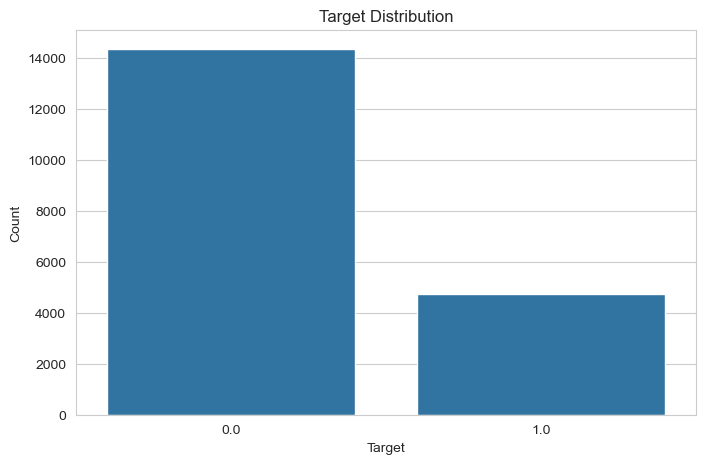

In [34]:
sns.countplot(x=y)
plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

Train-test split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15326, 158)
X_test shape: (3832, 158)
y_train shape: (15326,)
y_test shape: (3832,)


Feature scaling

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train the baseline SVM model

In [38]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

imputer = SimpleImputer(strategy="mean")
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)


svm_model = SVC(random_state=42, probability=True)
svm_model.fit(X_train_scaled, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Make predictions

In [39]:
y_pred = svm_model.predict(X_test_scaled)
y_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

Evaluate the baseline model

In [40]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7951
Precision: 0.5936
Recall   : 0.5644
F1-score : 0.5786
ROC-AUC  : 0.7982


Classification report

In [41]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.87      0.86      2877
         1.0       0.59      0.56      0.58       955

    accuracy                           0.80      3832
   macro avg       0.73      0.72      0.72      3832
weighted avg       0.79      0.80      0.79      3832



Confusion matrix

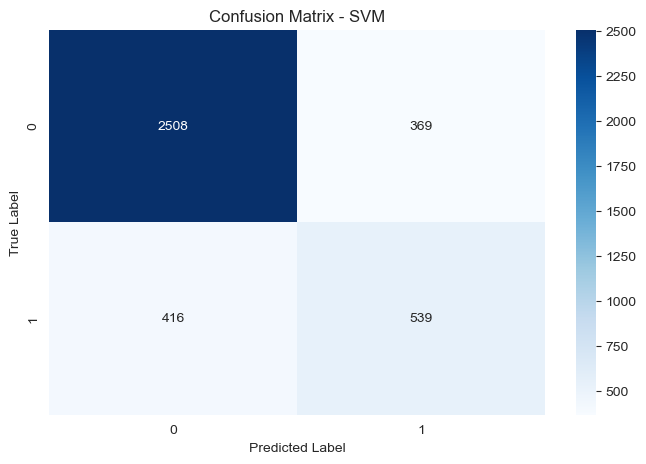

In [42]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

ROC curve

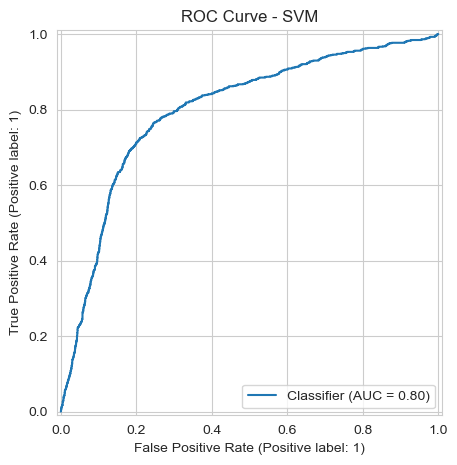

In [43]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("ROC Curve - SVM")
plt.show()

Cross-validation score

In [44]:
cv_scores = cross_val_score(
    SVC(random_state=42),
    X_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("Cross-validation F1 scores:", cv_scores)
print("Mean CV F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.54303709 0.51458489 0.51094891 0.53697057 0.55263158]
Mean CV F1 score: 0.5316346063199517


Hyperparameter tuning

In [45]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
    "class_weight": [None, "balanced"]
}

In [46]:
grid_search = GridSearchCV(
    SVC(random_state=42, probability=True),
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

KeyboardInterrupt: 

In [ ]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1 Score:", grid_search.best_score_)

Train the tuned model

In [ ]:
best_svm = grid_search.best_estimator_
best_svm.fit(X_train_scaled, y_train)

Predict with tuned model

In [ ]:
y_pred_best = best_svm.predict(X_test_scaled)
y_prob_best = best_svm.predict_proba(X_test_scaled)[:, 1]

Evaluate tuned model

In [ ]:
accuracy_best = accuracy_score(y_test, y_pred_best)
precision_best = precision_score(y_test, y_pred_best)
recall_best = recall_score(y_test, y_pred_best)
f1_best = f1_score(y_test, y_pred_best)
roc_auc_best = roc_auc_score(y_test, y_prob_best)

print("Tuned SVM Performance")
print("Accuracy :", round(accuracy_best, 4))
print("Precision:", round(precision_best, 4))
print("Recall   :", round(recall_best, 4))
print("F1-score :", round(f1_best, 4))
print("ROC-AUC  :", round(roc_auc_best, 4))